# 손가락 움직임 회귀(regression) 디코더로 AmazingHand 구동

`neural-to-output` 프로젝트와 독립적인 sandbox입니다 (`pyproject.toml`/`uv.lock` 미수정, `01_explore_eeg_decoder.ipynb`와
같은 `examples` 의존성 그룹만 사용합니다).

**목표**: `02_hand_intent_classification_amazinghand.ipynb`가 이산적인 grip/spread 두 클래스를 분류했다면,
이 노트북은 손가락마다 연속적인 굴곡도(flexion, 0=완전히 펴짐 ~ 1=완전히 쥐어짐)를 예측하는 **회귀** 디코더를
만들고, 그 출력을 `AmazingHand`까지 전달합니다. 02번 노트북과 마찬가지로, 실제 [AmazingHand]
(https://github.com/pollen-robotics/AmazingHand) CAD로 만든 MuJoCo 모델을 직접 관절 제어해서 손이
움직이는 모습을 봅니다.

**로봇 자유도(DoF) 관련 참고**: AmazingHand는 실제로 4개의 동일한 평행 메커니즘 손가락(`finger1`~`finger4`)을
가지고, 손가락마다 2개 서보(굴곡/신전용 `motor1`, 외전/내전용 `motor2`)로 움직이는 총 8-DoF 손입니다
(02번 노트북에서 쓴 것과 같은 CAD 모델 — 출처/라이선스는 `examples/assets/amazing_hand_right/NOTICE.md` 참고).
여기서는 그중 굴곡(`motor1`) 축만 손가락별로 연속값으로 예측하고, 외전(`motor2`) 축은 중립(0)으로 고정합니다.

**데이터셋 관련 캐비잇**: EEG와 손가락 운동학(kinematics)을 동시에 기록한 공개 데이터셋(예: WAY-EEG-GAL,
Luciw et al. 2014)은 실존하지만 수 GB 단위라 이 프로젝트의 `examples` 의존성 그룹에는 포함되어 있지 않습니다.
여기서는 손가락 굴곡도와 상관된 **합성(synthetic) 신호**로 회귀 디코더의 입출력 shape과 학습/추론 흐름을
보여줍니다 — 실제 기록으로 바꾸더라도 `n2o.signal.dataset`에 새 `SignalDataset` 구현 하나만 추가하면 아래
디코더/로봇 연결 코드는 그대로 재사용됩니다.

**하드웨어 관련 캐비잇**: `AmazingHand.move()`는 아직 실제 드라이버가 없는 인터페이스 스텁입니다
(`CLAUDE.md`, `docs/tutorials/adding-a-component.md` 참고). 이 노트북도 명령이 `AmazingHand`까지 올바른
형태로 전달되는 것을 보여주고, 실제 구동 확인은 MuJoCo 시뮬레이션(`AmazingHandSim`)으로 대체합니다.

In [1]:
import os

os.environ.setdefault(
    "MUJOCO_GL", "egl"
)  # 디스플레이 없는 환경에서도 오프스크린 렌더링

import matplotlib.pyplot as plt
import mujoco
import numpy as np
import torch
from IPython.display import HTML, display
from matplotlib import animation

from n2o import N2O
from n2o.command import ActionType, Command, CommandConfig
from n2o.decoder import Decoder, DecoderConfig, DecoderType, FeatureType
from n2o.robot.arm import MockArm
from n2o.robot.hand import AmazingHand, RobotHand

## 1. 합성 신호 생성

AmazingHand는 위에서 설명했듯 4개 손가락(`finger1`~`finger4`)을 가지므로, 여기서는 손가락마다 독립적인
굴곡도 하나씩 총 4-DoF(굴곡만, 외전은 중립 고정)를 예측 대상으로 합니다.

합성 신호는 각 채널의 진동 주파수가 그 채널이 대응하는 손가락의 굴곡도에 비례하도록 만들어서, 최소한
"신호와 타깃이 상관되어 있어 학습이 가능하다"는 성질만 갖도록 했습니다 — 실제 EEG의 생리학적 특성을
재현하지는 않습니다.

In [2]:
RNG = np.random.default_rng(0)  # 재현성

N_CHANS = 8
N_TIMES = 250  # 1s @ 250Hz 가정
FINGERS = ["finger1", "finger2", "finger3", "finger4"]


def make_synthetic_sample():
    """손가락 굴곡도(finger flexion)와 상관된 합성 신호 한 개를 만듭니다.

    실제 프로젝트에서는 이 함수 대신 `n2o.signal.dataset.SignalDataset`의 실제 구현
    (예: EEG+운동학 동시 기록 데이터셋을 감싼 클래스)의 `read()`가 이 자리를 대체합니다.
    """
    flexion = RNG.uniform(0, 1, size=len(FINGERS))
    t = np.linspace(0, 1, N_TIMES, endpoint=False)
    signal = np.stack(
        [
            np.sin(2 * np.pi * (5 + 3 * flexion[ch % len(flexion)]) * t)
            + RNG.normal(0, 0.3, N_TIMES)
            for ch in range(N_CHANS)
        ]
    )
    return signal.astype(np.float32), flexion.astype(np.float32)


X0, y0 = make_synthetic_sample()
print("합성 신호 shape (n_chans, n_times):", X0.shape)
print("손가락 굴곡도 targets:", dict(zip(FINGERS, y0.round(2))))

합성 신호 shape (n_chans, n_times): (8, 250)
손가락 굴곡도 targets: {'finger1': np.float32(0.64), 'finger2': np.float32(0.27), 'finger3': np.float32(0.04), 'finger4': np.float32(0.02)}


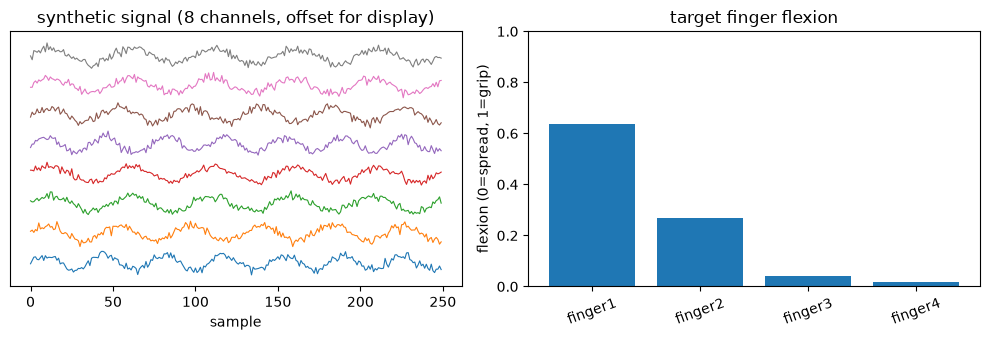

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

t = np.arange(N_TIMES)
for ch in range(N_CHANS):
    axes[0].plot(t, X0[ch] + ch * 4, linewidth=0.8)
axes[0].set_yticks([])
axes[0].set_xlabel("sample")
axes[0].set_title("synthetic signal (8 channels, offset for display)")

axes[1].bar(FINGERS, y0, color="tab:blue")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("flexion (0=spread, 1=grip)")
axes[1].set_title("target finger flexion")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 2. 학습/검증용 합성 데이터셋 만들기

`make_synthetic_sample()`을 여러 번 호출해서 작은 데이터셋을 만들고 train/valid로 나눕니다.

In [4]:
N_SAMPLES = 200
X_all = np.zeros((N_SAMPLES, N_CHANS, N_TIMES), dtype=np.float32)
y_all = np.zeros((N_SAMPLES, len(FINGERS)), dtype=np.float32)
for i in range(N_SAMPLES):
    X_all[i], y_all[i] = make_synthetic_sample()

n_train = 160
X_train, y_train = X_all[:n_train], y_all[:n_train]
X_valid, y_valid = X_all[n_train:], y_all[n_train:]
print(f"train samples: {len(X_train)}, valid samples: {len(X_valid)}")

train samples: 160, valid samples: 40


## 3. `Decoder` 서브클래스: 손가락 굴곡도 회귀 모델

작은 1D-conv 회귀 모델을 `n2o.decoder.Decoder`로 감싸서, `decode(signal)`이
`{"finger1": 0.0-1.0, "finger2": 0.0-1.0, ...}` 형태의 연속값 명령을 반환하도록 합니다. 마지막 레이어에
sigmoid를 둬서 출력을 굴곡도 범위인 [0, 1]로 제한합니다. `output_type = FeatureType.ACTION`으로 선언하고
`config.type`을 `DecoderType.REGRESSION`으로 표시합니다.

In [5]:
class FingerFlexionNet(torch.nn.Module):
    def __init__(self, n_chans, n_times, n_fingers):
        super().__init__()
        self.conv = torch.nn.Sequential(
            torch.nn.Conv1d(n_chans, 16, kernel_size=9, padding=4),
            torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool1d(1),
        )
        self.head = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(16, n_fingers),
            torch.nn.Sigmoid(),
        )

    def forward(self, x):
        return self.head(self.conv(x))


class FingerFlexionDecoder(Decoder):
    """손가락별 연속 굴곡도(flexion)를 예측하는 회귀 디코더."""

    output_type = FeatureType.ACTION

    def __init__(self, n_chans, n_times):
        self.input_spec = {"n_chans": n_chans, "n_times": n_times}
        self.output_spec = {finger: "flexion in [0, 1]" for finger in FINGERS}
        self.config = DecoderConfig(type=DecoderType.REGRESSION)
        self.model = FingerFlexionNet(n_chans, n_times, n_fingers=len(FINGERS))

    def decode(self, signal):
        self.model.eval()
        with torch.no_grad():
            x = torch.tensor(signal).unsqueeze(0).float()
            flexion = self.model(x)[0]
        return {finger: float(v) for finger, v in zip(FINGERS, flexion)}


class FingerFlexionCommand(Command):
    """decoded_signal이 손가락별 flexion 값 dict이므로, 자기 자신을 설명하지 못하는 raw
    regression 값이라 `ActionType.JOINT_ABSOLUTE`로 태그해서 hand 쪽에 묶어 전달합니다."""

    def translate(self, decoder, decoded_signal):
        return {
            "type": decoder.config.type,
            "arm": None,
            "hand": (ActionType.JOINT_ABSOLUTE, decoded_signal),
        }


decoder = FingerFlexionDecoder(n_chans=N_CHANS, n_times=N_TIMES)
print(decoder.model)

FingerFlexionNet(
  (conv): Sequential(
    (0): Conv1d(8, 16, kernel_size=(9,), stride=(1,), padding=(4,))
    (1): ReLU()
    (2): AdaptiveAvgPool1d(output_size=1)
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16, out_features=4, bias=True)
    (2): Sigmoid()
  )
)


## 4. 학습 sanity check (`MSELoss`)

분류가 아니라 회귀이므로 `CrossEntropyLoss` 대신 `MSELoss`를 씁니다. 합성 데이터 160개 전체를 반복
학습시켜서 loss가 떨어지는지만 확인합니다.

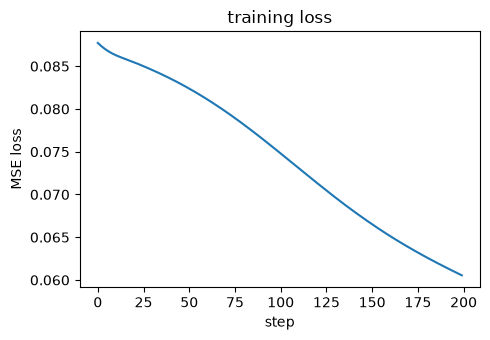

마지막 step MSE: 0.0605


In [6]:
decoder.model.train()
opt = torch.optim.Adam(decoder.model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

X_train_t = torch.from_numpy(X_train).float()
y_train_t = torch.from_numpy(y_train).float()

n_steps = 200
loss_history = []
for step in range(n_steps):
    opt.zero_grad()
    pred = decoder.model(X_train_t)
    loss = loss_fn(pred, y_train_t)
    loss.backward()
    opt.step()
    loss_history.append(loss.item())

plt.figure(figsize=(5, 3.5))
plt.plot(loss_history)
plt.xlabel("step")
plt.ylabel("MSE loss")
plt.title("training loss")
plt.tight_layout()
plt.show()

print(f"마지막 step MSE: {loss_history[-1]:.4f}")

## 5. 검증 샘플로 예측 vs 실제 비교

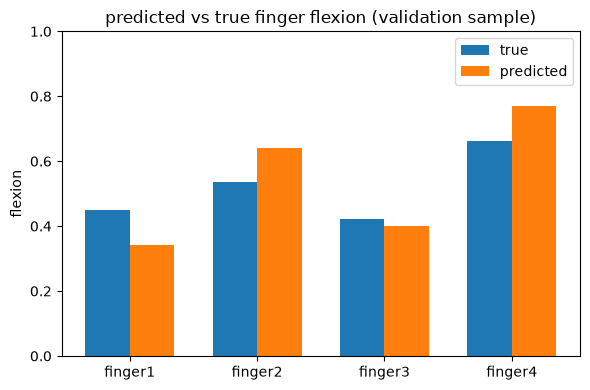

디코더 명령: {'finger1': 0.340967059135437, 'finger2': 0.6407396197319031, 'finger3': 0.401231974363327, 'finger4': 0.770205020904541}


In [7]:
sample_idx = 0
X_sample, y_sample = X_valid[sample_idx], y_valid[sample_idx]
predicted = decoder(X_sample)

x = np.arange(len(FINGERS))
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width / 2, y_sample, width, label="true")
ax.bar(x + width / 2, [predicted[f] for f in FINGERS], width, label="predicted")
ax.set_xticks(x)
ax.set_xticklabels(FINGERS)
ax.set_ylim(0, 1)
ax.set_ylabel("flexion")
ax.set_title("predicted vs true finger flexion (validation sample)")
ax.legend()
plt.tight_layout()
plt.show()

print("디코더 명령:", predicted)

## 6. MuJoCo로 실제 AmazingHand 모델 시각화하기

`02_hand_intent_classification_amazinghand.ipynb`와 같은 MuJoCo 모델(`examples/assets/amazing_hand_right/`)을
재사용하지만, 여기서는 이산적인 gesture 대신 손가락별 연속 굴곡도를 그대로 각 손가락의 굴곡(`motor{i}1`)
관절 목표값으로 선형 매핑합니다 (`flexion=0` -> `0 rad`(펴짐), `flexion=1` -> `1.4 rad`(쥐기); 외전
(`motor{i}2`)은 항상 중립인 0으로 둡니다).

In [8]:
ASSET_DIR = "assets/amazing_hand_right/mjcf"
FLEXION_TO_RAD = 1.4  # grip 판단 기준이었던 02번 노트북과 동일한 최대 굴곡 각도


class AmazingHandSim(RobotHand):
    """실제 AmazingHand MJCF 모델(MuJoCo)의 관절을 손가락별 연속 굴곡도로 직접 움직이는 RobotHand.

    실제 하드웨어(`AmazingHand.move()`)는 아직 구현되지 않았지만, 로봇 모델과 관절 이름은
    pollen-robotics/AmazingHand의 실제 CAD에서 나온 것입니다 (NOTICE.md 참고).
    """

    def __init__(self):
        self.input_spec = {finger: "flexion in [0, 1]" for finger in FINGERS}
        self.model = mujoco.MjModel.from_xml_path(f"{ASSET_DIR}/demo_scene.xml")
        self.data = mujoco.MjData(self.model)
        self.renderer = mujoco.Renderer(self.model, height=360, width=480)
        self.camera = mujoco.MjvCamera()
        mujoco.mjv_defaultCamera(self.camera)
        self.camera.distance = 0.35
        self.camera.azimuth = 120
        self.camera.elevation = -20
        self.camera.lookat = np.array([0.0, 0.0, 0.05])

    def _render_frame(self):
        self.renderer.update_scene(self.data, camera=self.camera)
        return self.renderer.render().copy()

    def _target_ctrl(self, flexion):
        target = np.zeros(2 * len(FINGERS))
        for i, finger in enumerate(FINGERS):
            target[2 * i] = flexion[finger] * FLEXION_TO_RAD  # motor1 = flexion
            # motor2 (외전)은 중립(0)으로 유지
        return target

    def move(self, decoder_type, command):
        _action_type, flexion = command
        target_ctrl = self._target_ctrl(flexion)
        start_ctrl = self.data.ctrl.copy()

        frames = []
        n_steps = 60
        for step in range(n_steps):
            alpha = (step + 1) / n_steps
            self.data.ctrl[:] = start_ctrl + alpha * (target_ctrl - start_ctrl)
            mujoco.mj_step(self.model, self.data)
            if step % 3 == 0:
                frames.append(self._render_frame())

        fig, ax = plt.subplots(figsize=(5, 4))
        im = ax.imshow(frames[0])
        ax.axis("off")
        flexion_str = ", ".join(f"{f}={flexion[f]:.2f}" for f in FINGERS)
        ax.set_title(f"AmazingHand (MuJoCo sim) -> {flexion_str}", fontsize=8)

        def update(i):
            im.set_data(frames[i])
            return [im]

        anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=60)
        plt.close(fig)
        display(HTML(anim.to_jshtml()))


sim_hand = AmazingHandSim()
sim_hand.move(
    DecoderType.REGRESSION,
    (
        ActionType.JOINT_ABSOLUTE,
        {"finger1": 0.0, "finger2": 0.0, "finger3": 0.0, "finger4": 0.0},
    ),
)
sim_hand.move(
    DecoderType.REGRESSION,
    (
        ActionType.JOINT_ABSOLUTE,
        {"finger1": 1.0, "finger2": 1.0, "finger3": 1.0, "finger4": 1.0},
    ),
)

## 7. `N2O` 파이프라인으로 AmazingHand까지 명령 전달

`02_hand_intent_classification_amazinghand.ipynb`와 동일한 패턴입니다: `AmazingHand.move()`가 아직
스텁이라 `n2o.run()`이 그 단계에서 `NotImplementedError`를 내고, `AmazingHandSim`으로 교체하면 디코더가
예측한 굴곡도대로 손가락이 움직이는 모습을 볼 수 있습니다.

In [9]:
class OneShotSignal:
    """decoder()에 넘길 신호 한 개를 반복해서 돌려주는 최소 signal 소스."""

    def __init__(self, sample):
        self.sample = sample

    def read(self):
        return self.sample


n2o = N2O()
n2o.signal = OneShotSignal(X_sample)
n2o.decoder = decoder
n2o.command = FingerFlexionCommand()
n2o.robot.arm = MockArm()
n2o.robot.hand = AmazingHand()

n2o.command_config = CommandConfig()
print(n2o.command_config.verify_report(n2o))

단계      | 출력 스펙                                                                                                      |    | 단계         | 입력 스펙                  | 상태
--------+------------------------------------------------------------------------------------------------------------+----+------------+------------------------+---
signal  | (미정)                                                                                                       | -> | decoder    | n_chans=8, n_times=250 | 미정
decoder | finger1=flexion in [0, 1], finger2=flexion in [0, 1], finger3=flexion in [0, 1], finger4=flexion in [0, 1] | -> | command    | (미정)                   | 미정
command | (미정)                                                                                                       | -> | robot.arm  | (미정)                   | 미정
command | (미정)                                                                                                       | -> | robot.hand | (미정)                   | 미정


In [10]:
try:
    n2o.run()
except NotImplementedError:
    print(
        "AmazingHand.move()는 아직 실제 하드웨어 드라이버가 구현되지 않은 인터페이스 스텁입니다"
        " (docs/tutorials/adding-a-component.md 참고)."
    )
    print(
        "실제 손 모델이 움직이는 모습을 보기 위해 AmazingHandSim(MuJoCo)으로 교체합니다.\n"
    )

n2o.robot.hand = sim_hand

# decoder.output_spec과 sim_hand.input_spec이 정확히 같은 형태({finger: flexion})이므로,
# 그 경계를 이어주는 command를 pass-through로 선언하면 verify_report()가 "match"로 확인해줍니다.
n2o.command_config = CommandConfig(
    input_feature=decoder.output_spec, output_feature=sim_hand.input_spec
)
print(n2o.command_config.verify_report(n2o))
print()
n2o.run()

MockArm.move(<DecoderType.REGRESSION: 'REGRESSION'>, None)
AmazingHand.move()는 아직 실제 하드웨어 드라이버가 구현되지 않은 인터페이스 스텁입니다 (docs/tutorials/adding-a-component.md 참고).
실제 손 모델이 움직이는 모습을 보기 위해 AmazingHandSim(MuJoCo)으로 교체합니다.

단계      | 출력 스펙                                                                                                      |    | 단계         | 입력 스펙                                                                                                      | 상태
--------+------------------------------------------------------------------------------------------------------------+----+------------+------------------------------------------------------------------------------------------------------------+---
signal  | (미정)                                                                                                       | -> | decoder    | n_chans=8, n_times=250                                                                                     | 미정
decoder | finger1=flexion in [0, 1], 

## 정리

- `Decoder` ABC를 상속한 회귀 모델이 `{finger_name: flexion}` 형태의 연속값 명령을 만들었고,
  `config.type = DecoderType.REGRESSION`으로 표시했습니다.
- AmazingHand의 실제 자유도(4개 손가락 x 굴곡/외전 2축)에 맞춰 `FINGERS`를 `finger1`~`finger4`로 두고,
  굴곡 축만 예측했습니다 (외전은 중립 고정). 합성 데이터와 `MSELoss` 기반 sanity-check 학습이라는 단순화
  지점은 남아있으니, 실제 EEG+운동학 데이터셋으로 교체할 때 그 부분만 바꾸면 됩니다.
- 회귀가 내놓는 raw flexion 값은 그 자체로 의미를 설명하지 못하므로, `FingerFlexionCommand`가
  `(ActionType.JOINT_ABSOLUTE, {finger: flexion, ...})` 튜플로 태그해서 `robot.hand.move()`에 전달합니다
  (02번 노트북의 분류 결과가 `"grip"`처럼 이미 자기 설명적인 이름이었던 것과 대비됩니다).
- `AmazingHand.move()`가 구현되기 전까지는, `02_hand_intent_classification_amazinghand.ipynb`와 같은
  실제 CAD 기반 MuJoCo 모델을 직접 관절 제어해서 예측한 굴곡도대로 손가락이 움직이는 모습을 확인할 수
  있습니다 (`AmazingHandSim`). `CommandConfig.verify_report()`도 command를 pass-through로 선언하면 그
  경계가 "match"로 뜨는 것을 확인했습니다.
- `02_hand_intent_classification_amazinghand.ipynb`(분류)와 이 노트북(회귀)은 같은 `Decoder`/`N2O`/
  `AmazingHand`/`AmazingHandSim` 인터페이스를 공유하므로, 두 방식 중 어느 쪽으로 개발하더라도 로봇 손
  연결 코드는 동일합니다 (다만 raw 값 여부에 따라 `Command`가 붙이는 태그는 달라집니다).